Zadanie 4

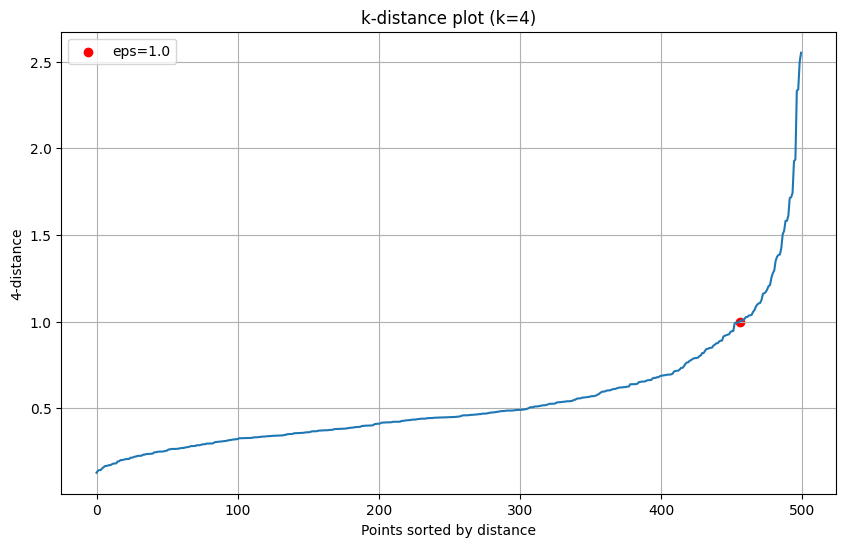

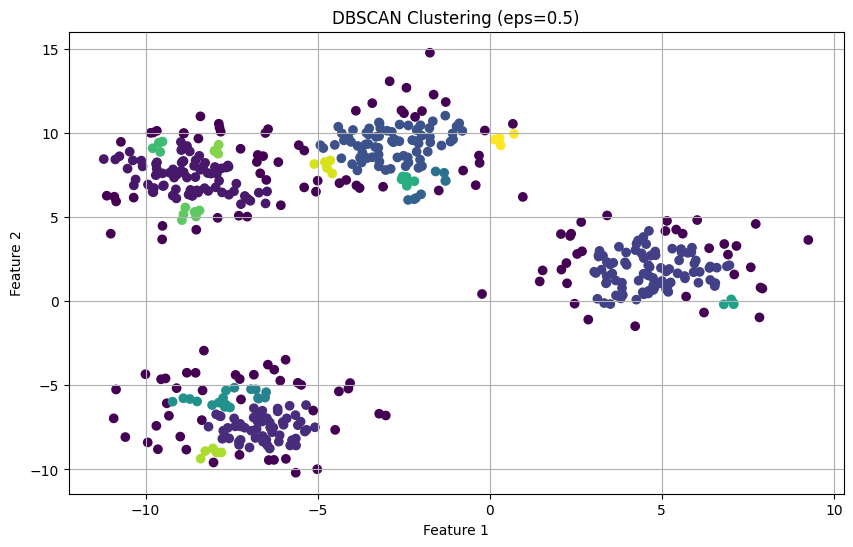

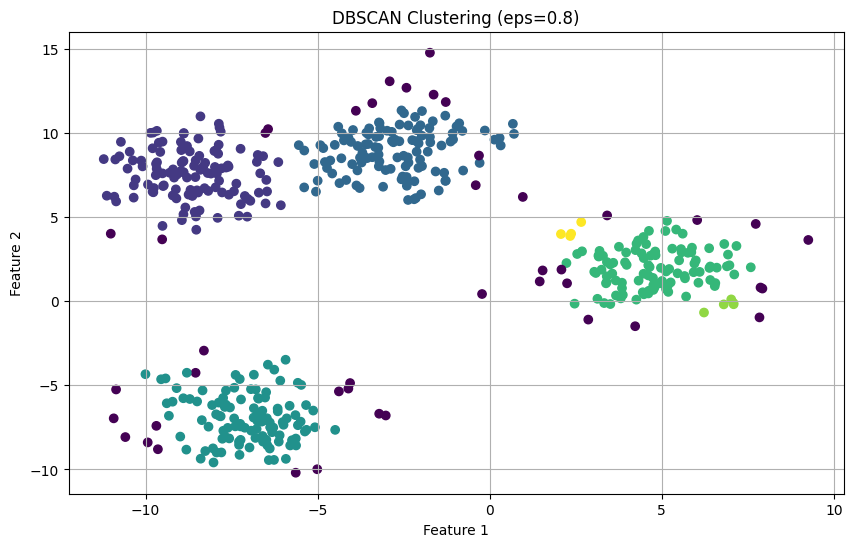

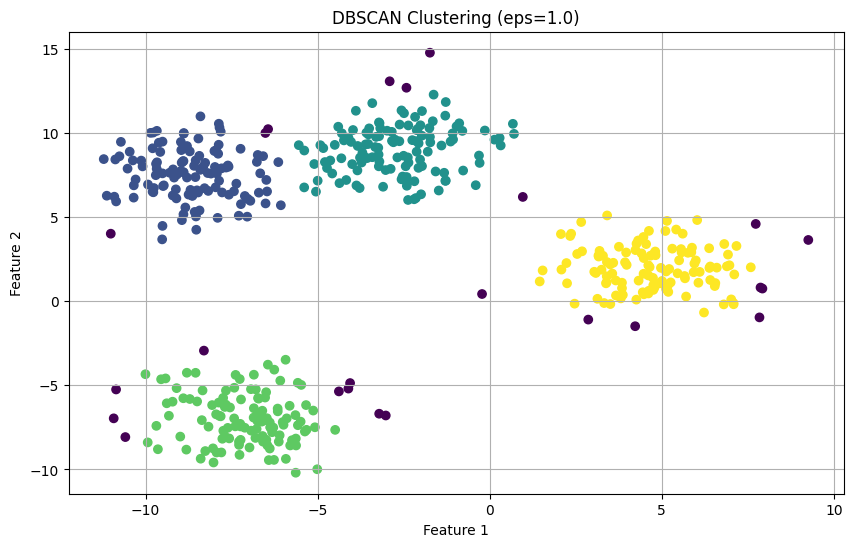

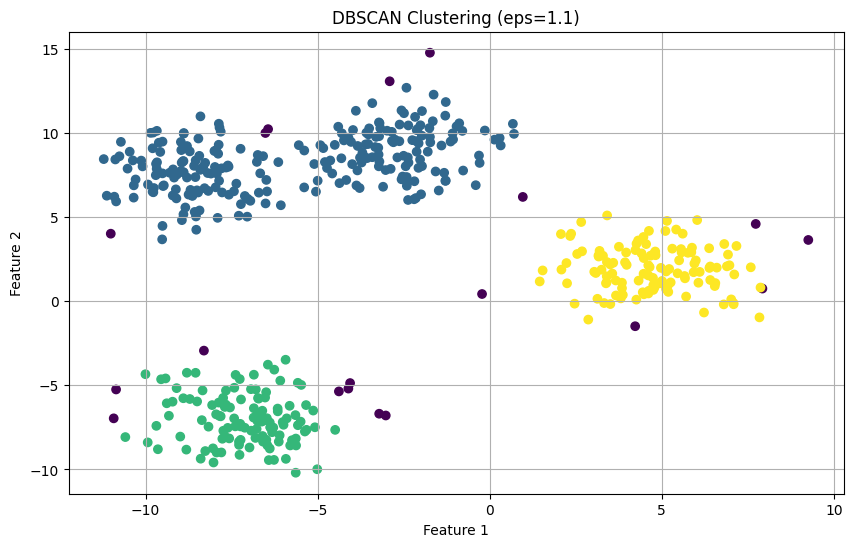

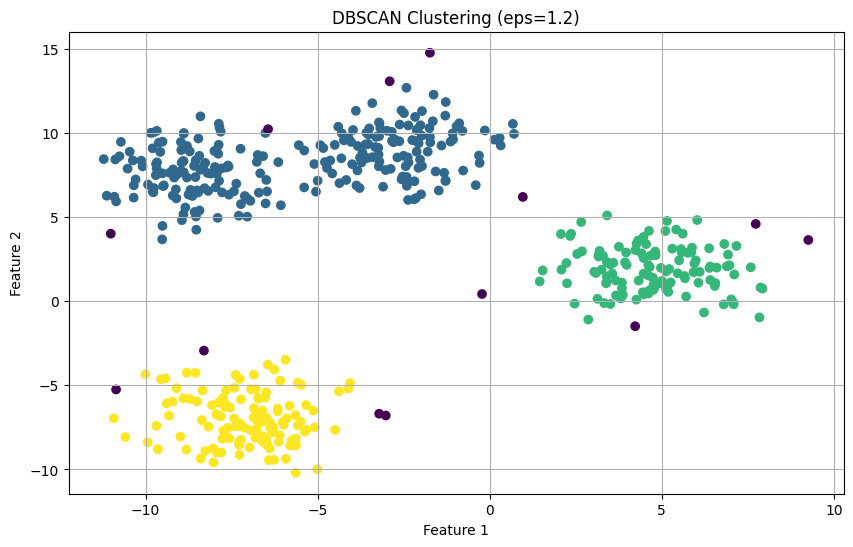

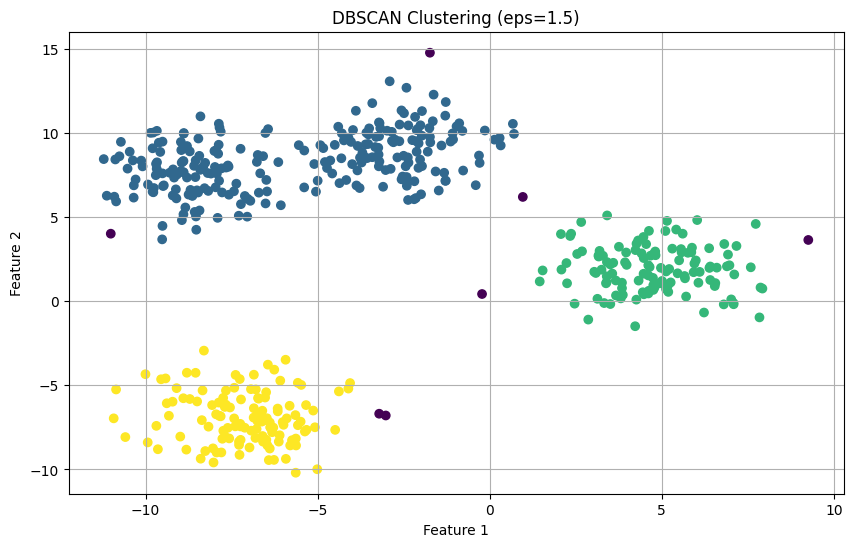

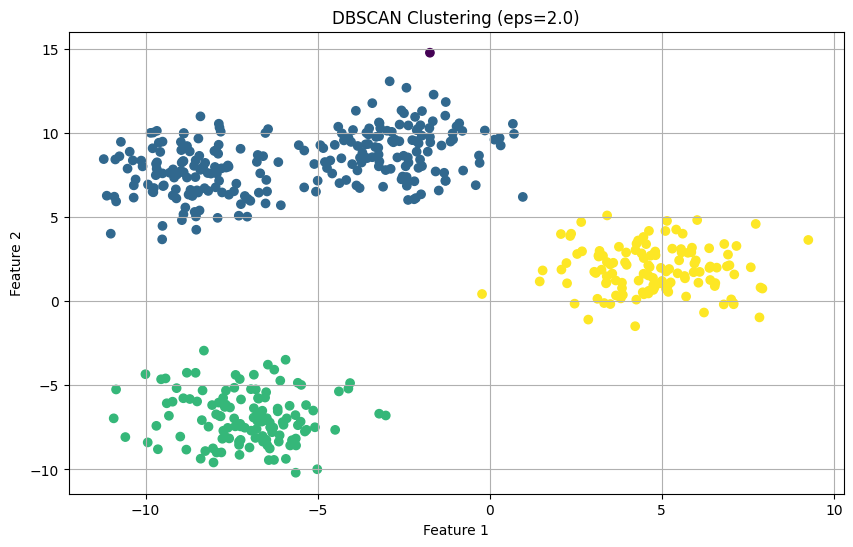

In [10]:
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

X, _ = make_blobs(n_samples=500, centers=4, cluster_std=1.5, random_state=42)

k = 4  # liczba sąsiadów
neigh = NearestNeighbors(n_neighbors=k)
neigh.fit(X)
distances, _ = neigh.kneighbors(X)

k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{k}-distance')
plt.title(f'k-distance plot (k={k})')

eps_value = 1.0
plt.scatter(np.where(k_distances >= eps_value)[0][0], eps_value, color='red', label=f'eps={eps_value}')
plt.legend()
plt.grid()
plt.show()

eps_values = [0.5, 0.8, 1.0, 1.1, 1.2, 1.5, 2.0]
for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=k)
    labels = dbscan.fit_predict(X)
    plt.figure(figsize=(10, 6))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', marker='o')
    plt.title(f'DBSCAN Clustering (eps={eps})')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid()
    plt.show()

Zadanie 7

In [7]:
from sklearn.ensemble import IsolationForest
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

iris = load_iris()
X = iris.data

iso_forest = IsolationForest(contamination=0.1, random_state=42)
iso_labels = iso_forest.fit_predict(X)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
centroids = kmeans.cluster_centers_

distances_to_centroids = np.linalg.norm(X - centroids[kmeans.labels_], axis=1)

anomalies_kmeans = np.where(distances_to_centroids > 1.5)[0]

anomalies_iso = np.where(iso_labels == -1)[0]

print("Anomalie z Isolation Forest:", anomalies_iso)
print("Anomalie z k-Means:", anomalies_kmeans)
iso_set = set(anomalies_iso)
kmeans_set = set(anomalies_kmeans)  
intersection = list(iso_set.intersection(kmeans_set))
print("Wspólne anomalie:", intersection)

Anomalie z Isolation Forest: [ 13  14  15  22  32  33  41  60  62  98 109 117 118 122 131]
Anomalie z k-Means: [ 57  60  93  98 118]
Wspólne anomalie: [np.int64(98), np.int64(60), np.int64(118)]
